## Logistics Delay Prediction

* Imports:

In [ ]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

from sklearn.metrics import recall_score, precision_score



RANDOM_STATE = 2026
sns.set_theme(style="whitegrid")

* Funciones auxiliares:

In [104]:
def hhmmss_to_minutes(s: str) -> int:
    """HH:MM:SS -> minutos del día"""
    h, m, _ = s.split(":")
    return int(h) * 60 + int(m)

def minutes_to_hhmmss_day(m: int) -> str:
    """minutos (puede pasar 24h o ser negativo) -> HH:MM:SS del día (0..23:59)"""
    m = int(m) % 1440
    h = m // 60
    mm = m % 60
    return f"{h:02d}:{mm:02d}:00"

def minutos_a_hhmmss(mins: float) -> str:
    """minutos (duración) -> HH:MM:SS (con signo si es negativo)"""
    sign = "-" if mins < 0 else ""
    mins = abs(int(round(mins)))
    h = mins // 60
    m = mins % 60
    return f"{sign}{h:02d}:{m:02d}:00"

def clasificar_riesgo(x: float) -> str:
    if x >= 30:
        return "Alto"
    elif x >= 15:
        return "Medio"
    return "Bajo"

In [105]:
import os

current_working_directory = os.getcwd()
print("Current working directory:", current_working_directory)



Current working directory: c:\Users\paulo\logistics-ml\Notebook


In [106]:
# Cargar el dataset
dataset = pd.read_csv("../data/raw/logistics_24h_hhmmss.csv")
dataset.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/logistics_24h_hhmmss.csv'

* Calidad de datos:

In [7]:
print("Shape:", dataset.shape)
display(dataset.info())
display(dataset.describe(include="all"))

print("\nNulos:")
display(dataset.isnull().sum())

print("\nDuplicados:", dataset.duplicated().sum())

Shape: (35250, 10)
<class 'pandas.DataFrame'>
RangeIndex: 35250 entries, 0 to 35249
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   semana                 35250 non-null  int64  
 1   empresa                35250 non-null  str    
 2   patente                35250 non-null  str    
 3   tipo_operacion         35250 non-null  str    
 4   tipo_carga             35250 non-null  str    
 5   hora_programada        35250 non-null  str    
 6   hora_ingreso_real      35250 non-null  str    
 7   hora_inicio_operacion  35250 non-null  str    
 8   hora_fin_operacion     35250 non-null  str    
 9   minutos_atraso         35250 non-null  float64
dtypes: float64(1), int64(1), str(8)
memory usage: 2.7 MB


None

,semana,empresa,patente,tipo_operacion,tipo_carga,hora_programada,hora_ingreso_real,hora_inicio_operacion,hora_fin_operacion,minutos_atraso
count,35250.000000,35250,35250,35250,35250,35250,35250,35250,35250,35250.000000
unique,NaN,15,80,2,2,1440,1440,1440,1440,NaN
top,NaN,Nivalis CargoWorks,TRK-060,Despacho,Pallet,14:38:00,11:33:00,12:05:00,18:25:00,NaN
freq,NaN,3439,485,19462,24659,54,56,65,60,NaN
mean,26.416823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.310207
std,15.073271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.536961
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-49.090000
25%,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.412500
50%,26.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.640000
75%,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.540000



Nulos:


semana                   0
empresa                  0
patente                  0
tipo_operacion           0
tipo_carga               0
hora_programada          0
hora_ingreso_real        0
hora_inicio_operacion    0
hora_fin_operacion       0
minutos_atraso           0
dtype: int64


Duplicados: 0


## EDA

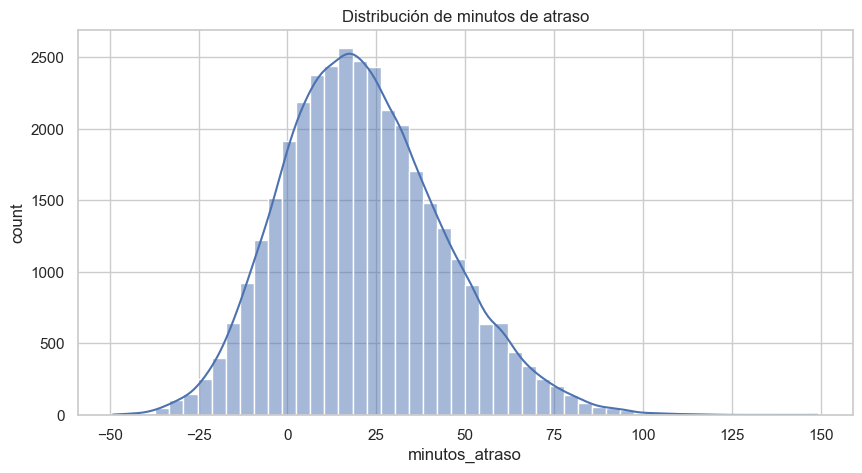

In [70]:
#Distribución de minutos de atraso
plt.figure(figsize=(10,5))
sns.histplot(dataset["minutos_atraso"], bins=50, kde=True)
plt.title("Distribución de minutos de atraso")
plt.xlabel("minutos_atraso")
plt.ylabel("count")
plt.show()


La distribución de minutos de atraso presenta una forma aproximadamente normal con ligera asimetría positiva.

La mayoría de las operaciones se concentran entre 0 y 40 minutos de atraso, con un promedio cercano a los 20 minutos.

Se observan eventos extremos superiores a 80 minutos, los cuales representan riesgos operacionales significativos.

La presencia de cola derecha y valores extremos justifica el uso de modelos no lineales capaces de capturar comportamientos no simétricos.

In [42]:
# % de llegadas tarde (Global)
dataset["llego_tarde"] = dataset["minutos_atraso"] > 0
tasa_global = dataset["llego_tarde"].mean() * 100
print(f"Tasa global de llegadas tarde: {tasa_global:.2f}%")

Tasa global de llegadas tarde: 82.91%


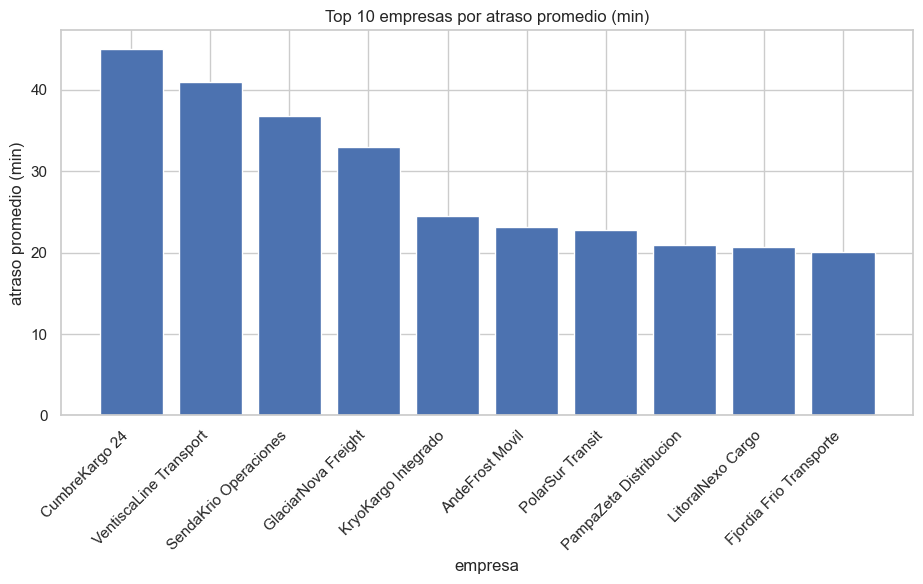

In [43]:
# Top 10 empresas por atraso promedio
top_emp = dataset.groupby("empresa")["minutos_atraso"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(11,5))
plt.bar(top_emp.index, top_emp.values)
plt.title("Top 10 empresas por atraso promedio (min)")
plt.xlabel("empresa")
plt.ylabel("atraso promedio (min)")
plt.xticks(rotation=45, ha="right")
plt.show()

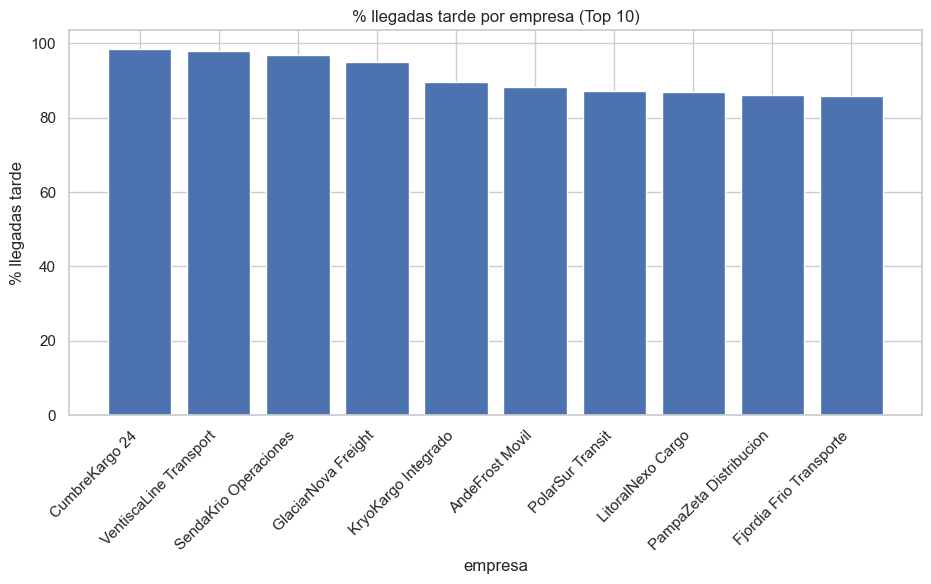

In [44]:
#Llegadas tarde por empresa (Top 10)
top_tasa = (dataset.groupby("empresa")["llego_tarde"].mean() * 100).sort_values(ascending=False).head(10)

plt.figure(figsize=(11,5))
plt.bar(top_tasa.index, top_tasa.values)
plt.title("% llegadas tarde por empresa (Top 10)")
plt.xlabel("empresa")
plt.ylabel("% llegadas tarde")
plt.xticks(rotation=45, ha="right")
plt.show()

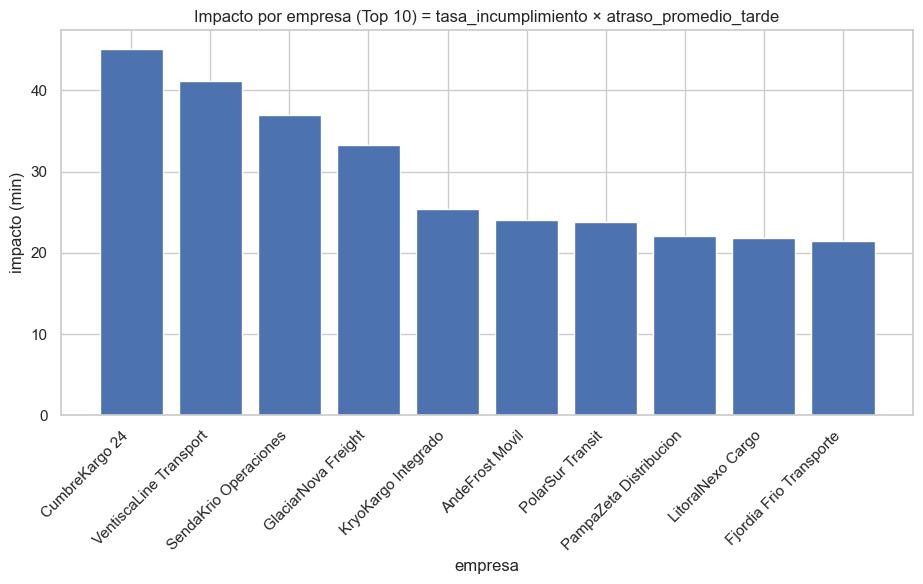

,total_ops,tasa_inc,atraso_prom_tarde,impacto
empresa,,,,
CumbreKargo 24,1057,0.984863,45.818012,45.124456
VentiscaLine Transport,1731,0.977470,42.050366,41.102958
SendaKrio Operaciones,2159,0.968504,38.226777,37.022784
GlaciarNova Freight,2804,0.950071,35.076062,33.324761
KryoKargo Integrado,2446,0.894113,28.449781,25.437314
AndeFrost Movil,2485,0.881690,27.318539,24.086487
PolarSur Transit,2153,0.872271,27.259542,23.777715
PampaZeta Distribucion,2090,0.860766,25.633013,22.064014
LitoralNexo Cargo,2170,0.867742,25.091004,21.772516


In [45]:
# Impacto por empresa = tasa_incumplimiento × atraso_promedio_tarde
def mean_if_tarde(s):
    s = s[s > 0]
    return float(s.mean()) if len(s) else 0.0

perf = dataset.groupby("empresa").agg(
    total_ops=("minutos_atraso","size"),
    tasa_inc=("llego_tarde","mean"),
    atraso_prom_tarde=("minutos_atraso", mean_if_tarde),
)
perf["impacto"] = perf["tasa_inc"] * perf["atraso_prom_tarde"]
top_impacto = perf.sort_values("impacto", ascending=False).head(10)

plt.figure(figsize=(11,5))
plt.bar(top_impacto.index, top_impacto["impacto"].values)
plt.title("Impacto por empresa (Top 10) = tasa_incumplimiento × atraso_promedio_tarde")
plt.xlabel("empresa")
plt.ylabel("impacto (min)")
plt.xticks(rotation=45, ha="right")
plt.show()

top_impacto

## Empresas con Mayor Impacto Operacional

No todas las empresas afectan de la misma manera la operación logística.

Para identificar cuáles generan mayor problema, se construyó un indicador llamado **Impacto Operacional**, que combina dos factores clave:

- **Tasa de incumplimiento**: porcentaje de operaciones que llegan tarde.
- **Atraso promedio cuando se atrasan**: cantidad promedio de minutos de retraso considerando solo las operaciones tardías.

El indicador se calcula de la siguiente forma:

Impacto = Tasa de incumplimiento × Atraso promedio (operaciones tardías)

Donde:

Tasa de incumplimiento = Operaciones tardías / Total de operaciones

Este cálculo permite combinar:

- La **frecuencia del problema** (qué tan seguido ocurre)
- La **gravedad del problema** (qué tan grande es cuando ocurre)

De esta manera, no solo se observa quién tiene más atrasos, sino quién genera mayor efecto total en la operación.

Por ejemplo, una empresa puede atrasarse pocas veces pero con retrasos muy largos, mientras otra puede atrasarse muchas veces pero solo algunos minutos.  
El indicador equilibra ambos factores y ayuda a priorizar aquellas empresas que realmente representan mayor riesgo operativo.

En términos prácticos, este análisis permite enfocar acciones correctivas donde el beneficio potencial es mayor.

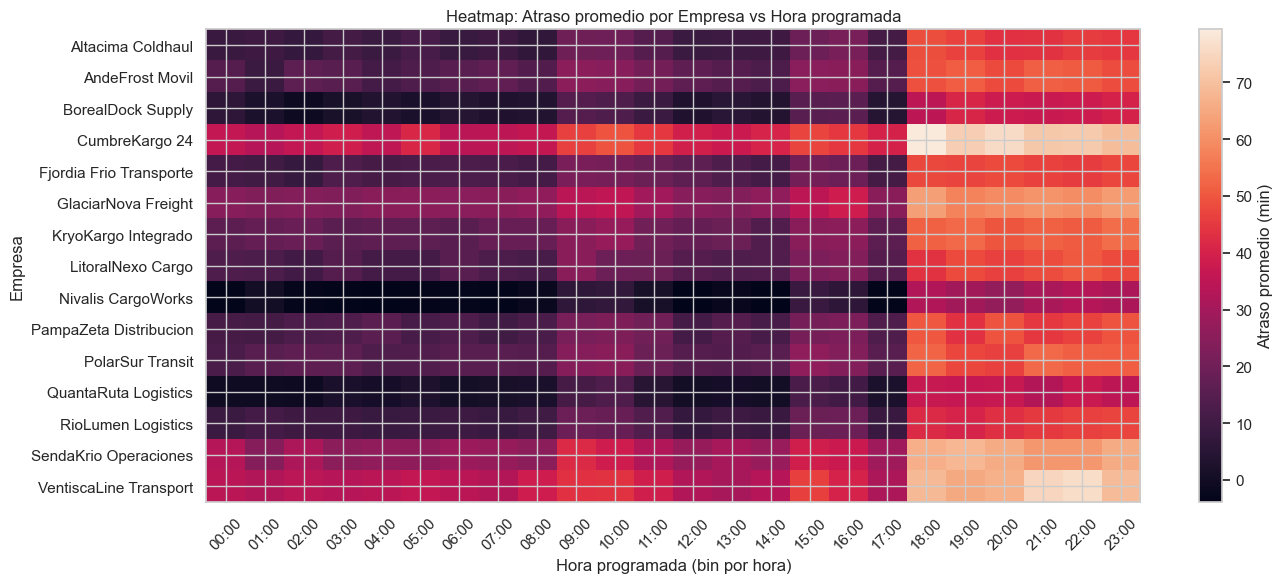

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- helper: HH:MM:SS -> minuto del día ---
def hhmmss_to_min(s: str) -> int:
    h, m, _ = s.split(":")
    return int(h)*60 + int(m)

df_eda = dataset.copy()
df_eda["hora_programada_min"] = df_eda["hora_programada"].apply(hhmmss_to_min)
df_eda["hora_bin"] = (df_eda["hora_programada_min"] // 60)  # bins por hora (0..23)

# pivot: filas empresa, columnas hora, valores atraso promedio
pivot = df_eda.pivot_table(
    index="empresa",
    columns="hora_bin",
    values="minutos_atraso",
    aggfunc="mean"
)

plt.figure(figsize=(14,6))
plt.imshow(pivot, aspect="auto")  # no fijamos colores manualmente
plt.colorbar(label="Atraso promedio (min)")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(24), [f"{h:02d}:00" for h in range(24)], rotation=45)
plt.title("Heatmap: Atraso promedio por Empresa vs Hora programada")
plt.xlabel("Hora programada (bin por hora)")
plt.ylabel("Empresa")
plt.tight_layout()
plt.show()

## Atraso promedio por Empresa y Hora programada

El heatmap muestra cómo varía el atraso promedio según la empresa y la hora programada.

Se observa un patrón consistente de aumento en los minutos de atraso a partir de las 18:00 horas, lo que sugiere posibles efectos de congestión, menor dotación operativa o acumulación de retrasos durante la jornada.

Asimismo, no todas las empresas presentan el mismo comportamiento: algunas mantienen niveles bajos de atraso de forma relativamente estable, mientras que otras muestran incrementos significativos en horarios específicos.

Este análisis confirma que el atraso no es un fenómeno homogéneo, sino que depende tanto del proveedor como del contexto horario, lo que refuerza la necesidad de modelos predictivos capaces de capturar interacciones no lineales entre variables.

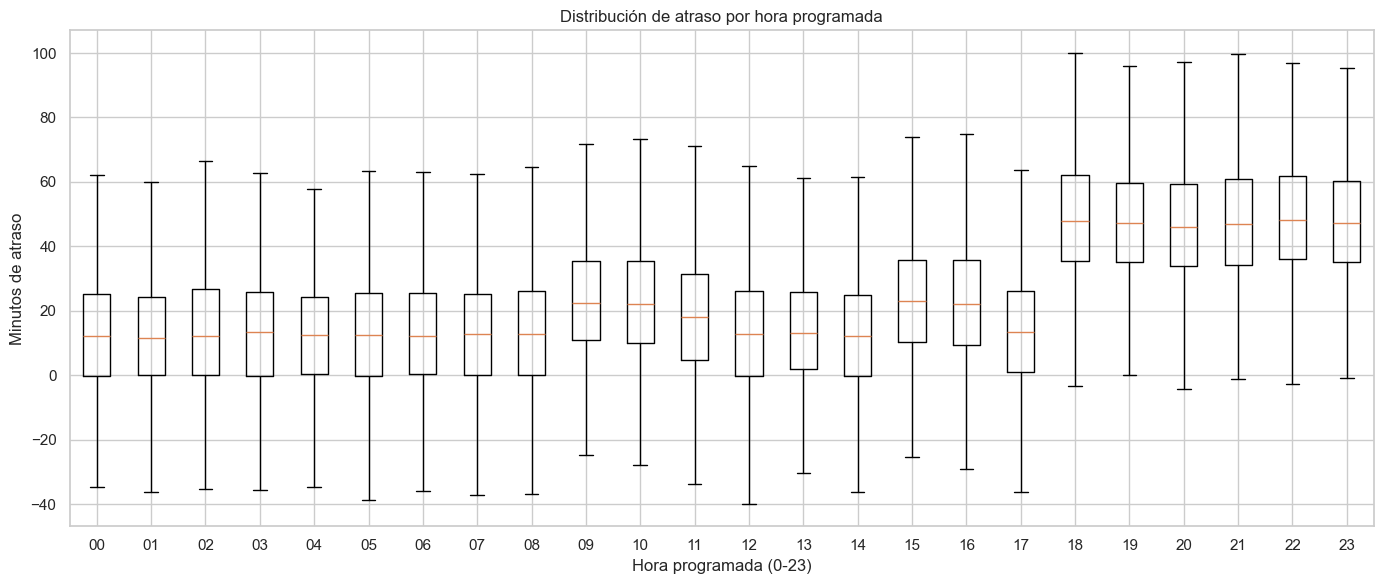

In [72]:
import matplotlib.pyplot as plt

df_eda = dataset.copy()
df_eda["hora_programada_min"] = df_eda["hora_programada"].apply(hhmmss_to_min)
df_eda["hora_bin"] = (df_eda["hora_programada_min"] // 60)

data_by_hour = [df_eda.loc[df_eda["hora_bin"]==h, "minutos_atraso"].values for h in range(24)]

plt.figure(figsize=(14,6))
plt.boxplot(data_by_hour, showfliers=False)
plt.xticks(range(1,25), [f"{h:02d}" for h in range(24)], rotation=0)
plt.xlabel("Hora programada (0-23)")
plt.ylabel("Minutos de atraso")
plt.title("Distribución de atraso por hora programada")
plt.tight_layout()
plt.show()

## Distribución del atraso según hora programada

El análisis por hora muestra un comportamiento estructural claro en los atrasos operacionales.

Durante la madrugada y primeras horas del día (00:00–08:00), los atrasos son relativamente bajos y presentan menor variabilidad. 

A partir de las 09:00 se observa un incremento en la mediana del atraso, junto con mayor dispersión, lo que sugiere acumulación operativa durante la jornada.

El efecto más significativo ocurre entre las 18:00 y 23:00 horas, donde se registra un aumento considerable tanto en el atraso promedio como en la variabilidad, incluyendo casos extremos superiores a 80 minutos.

Este patrón indica que la hora programada es un factor determinante en el desempeño logístico, y que el riesgo operacional aumenta significativamente en horario nocturno.

In [ ]:
# Atrasos (minutos) por tipo de operación y tipo de carga
display(dataset.groupby("tipo_operacion")["minutos_atraso"].mean())
display(dataset.groupby("tipo_carga")["minutos_atraso"].mean())
display(dataset.groupby("empresa")["minutos_atraso"].mean())

tipo_operacion
Despacho     18.388163
Recepcion    24.912236
Name: minutos_atraso, dtype: float64

tipo_carga
Carga Suelta    24.084786
Pallet          20.118530
Name: minutos_atraso, dtype: float64

empresa
Altacima Coldhaul          17.552342
AndeFrost Movil            23.116402
BorealDock Supply          11.674585
CumbreKargo 24             45.044428
Fjordia Frio Transporte    20.127736
GlaciarNova Freight        32.978252
KryoKargo Integrado        24.513557
LitoralNexo Cargo          20.713562
Nivalis CargoWorks          5.122809
PampaZeta Distribucion     20.890459
PolarSur Transit           22.768481
QuantaRuta Logistics        9.320179
RioLumen Logistics         16.725823
SendaKrio Operaciones      36.780866
VentiscaLine Transport     40.951999
Name: minutos_atraso, dtype: float64

In [ ]:
# Copiar para no ensuciar el dataset original
data = dataset.copy()

#ya existe hora_programada_min, aseguramos que está
if "hora_programada_min" not in data.columns:
    data["hora_programada_min"] = data["hora_programada"].apply(hhmmss_to_minutes)

X = data[[
    "semana",
    "empresa",
    "patente",
    "tipo_operacion",
    "tipo_carga",
    "hora_programada_min"
]]
y = data["minutos_atraso"]

In [ ]:
# Preprocesamiento: OneHot para categóricas, passthrough para numéricas
categorical = ["empresa", "patente", "tipo_operacion", "tipo_carga"]
numeric = ["semana", "hora_programada_min"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric),
    ]
)
# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [ ]:
# Modelo de regresión lineal
lin = Pipeline([
    ("prep", preprocess),
    ("model", LinearRegression())
])

lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)

print("=== Linear Regression ===")
print("MAE:", mean_absolute_error(y_test, pred_lin))
print("R2 :", r2_score(y_test, pred_lin))

=== Linear Regression ===
MAE: 13.314159317912733
R2 : 0.44126073839769586


In [101]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [102]:
# Modelo de Random Forest
rf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=350,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("R2 :", r2_score(y_test, pred_rf))

Random Forest
MAE: 12.423644761904763
R2 : 0.5119894062926681


In [ ]:
# Validación cruzada para Random Forest
scores_rf = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)
print("Random Forest CV MAE:", -scores_rf.mean())

Random Forest CV MAE: 12.502718089159066


In [ ]:
xgb = Pipeline([
    ("prep", preprocess),
    ("model", XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

print("XGBoost Regressor")
print("MAE:", mean_absolute_error(y_test, pred_xgb))
print("R2 :", r2_score(y_test, pred_xgb))

XGBoost Regressor
MAE: 11.654461986630743
R2 : 0.5715744353966559


In [ ]:
# Validación cruzada para XGBoost
scores_xgb = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("XGB CV MAE:", -scores_xgb.mean())

XGB CV MAE: 11.66724479113231


In [ ]:
resultados = pd.DataFrame({
    "modelo": ["Linear", "RandomForest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, pred_lin),
        mean_absolute_error(y_test, pred_rf),
        mean_absolute_error(y_test, pred_xgb),
    ],
    "R2": [
        r2_score(y_test, pred_lin),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_xgb),
    ]
}).sort_values("MAE")

resultados

,modelo,MAE,R2
2,XGBoost,11.654462,0.571574
1,RandomForest,12.423645,0.511989
0,Linear,13.314159,0.441261


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2 = r2_score(y_test, pred_xgb)

print("=== Evaluación del modelo ===")
print(f"MAE  : {mae:.2f} min")
print(f"RMSE : {rmse:.2f} min")
print(f"R2   : {r2:.3f}")

=== Evaluación del modelo ===
MAE  : 11.65 min
RMSE : 14.67 min
R2   : 0.572


In [ ]:
def evaluar_criticos(y_true, y_pred, threshold=30):
    y_true_bin = y_true > threshold
    y_pred_bin = y_pred > threshold

    from sklearn.metrics import recall_score, precision_score

    return (
        recall_score(y_true_bin, y_pred_bin),
        precision_score(y_true_bin, y_pred_bin)
    )

rec_lin = evaluar_criticos(y_test, pred_lin)
rec_rf = evaluar_criticos(y_test, pred_rf)
rec_xgb = evaluar_criticos(y_test, pred_xgb)

comparacion = pd.DataFrame({
    "Modelo": ["Linear", "RandomForest", "XGBoost"],
    "Recall_>30": [rec_lin[0], rec_rf[0], rec_xgb[0]],
    "Precision_>30": [rec_lin[1], rec_rf[1], rec_xgb[1]]
})

comparacion

,Modelo,Recall_>30,Precision_>30
0,Linear,0.585472,0.687787
1,RandomForest,0.629404,0.747417
2,XGBoost,0.623314,0.768777


In [ ]:
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


In [ ]:
best_model_name = "xgboost"
pred_best = pred_xgb

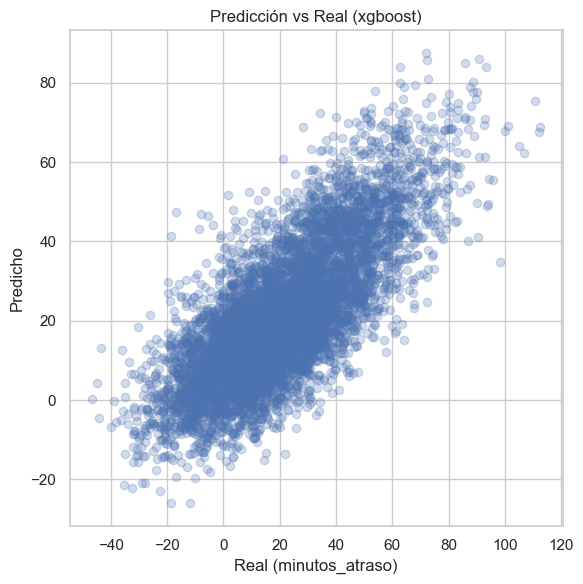

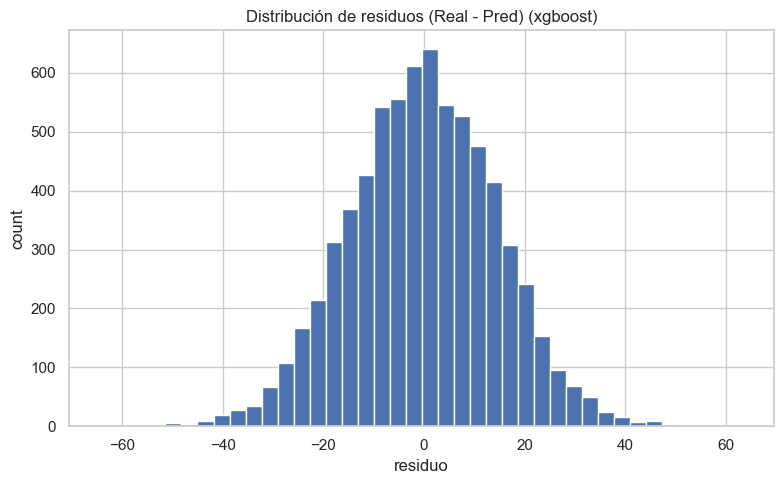

In [ ]:
ensure_dir("outputs/figures")

# Pred vs Real
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_best, alpha=0.25)
plt.title(f"Predicción vs Real ({best_model_name})")
plt.xlabel("Real (minutos_atraso)")
plt.ylabel("Predicho")
plt.tight_layout()
plt.savefig(f"outputs/figures/pred_vs_real_{best_model_name}.png", dpi=150)
plt.show()

# Residuos
resid = y_test - pred_best
plt.figure(figsize=(8,5))
plt.hist(resid, bins=40)
plt.title(f"Distribución de residuos (Real - Pred) ({best_model_name})")
plt.xlabel("residuo")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(f"outputs/figures/residuos_{best_model_name}.png", dpi=150)
plt.show()

In [ ]:
#Umbral vs Recall/Precision
def threshold_report(y_true, y_pred, pred_threshold, real_threshold=30):
    y_true_bin = y_true > real_threshold
    y_pred_bin = y_pred > pred_threshold
    return {
        "Umbral_pred": pred_threshold,
        "Alertas_generadas": int(y_pred_bin.sum()),
        "Criticos_reales": int(y_true_bin.sum()),
        "Recall": recall_score(y_true_bin, y_pred_bin),
        "Precision": precision_score(y_true_bin, y_pred_bin),
    }

# Barrido
thresholds = np.arange(15, 45, 2)
grid = pd.DataFrame([threshold_report(y_test, pred_best, t) for t in thresholds])
grid

,Umbral_pred,Alertas_generadas,Criticos_reales,Recall,Precision
0,15,4209,2299,0.933449,0.509860
1,17,3868,2299,0.909961,0.540848
2,19,3487,2299,0.879078,0.579581
3,21,3110,2299,0.840365,0.621222
4,23,2779,2299,0.796868,0.659230
5,25,2510,2299,0.755546,0.692032
6,27,2238,2299,0.705959,0.725201
7,29,1988,2299,0.650283,0.752012
8,31,1775,2299,0.605046,0.783662
9,33,1587,2299,0.560679,0.812224


In [ ]:
# Escoger el que maximiza F1 (balance)
grid["F1"] = 2 * (grid["Precision"] * grid["Recall"]) / (grid["Precision"] + grid["Recall"])
best_threshold = int(grid.sort_values("F1", ascending=False).iloc[0]["Umbral_pred"])


In [ ]:
cmp = pd.DataFrame([
    threshold_report(y_test, pred_best, 30),
    threshold_report(y_test, pred_best, best_threshold),
])
cmp

,Umbral_pred,Alertas_generadas,Criticos_reales,Recall,Precision
0,30,1864,2299,0.623314,0.768777
1,25,2510,2299,0.755546,0.692032


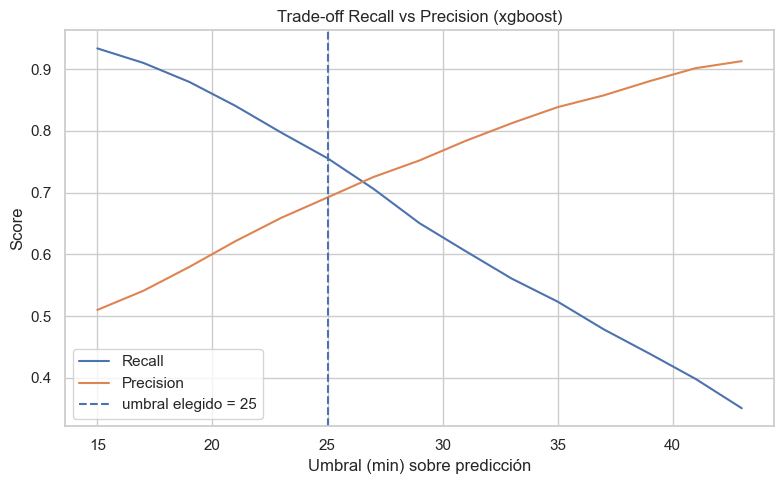

In [ ]:
ensure_dir("outputs/figures")

plt.figure(figsize=(8,5))
plt.plot(grid["Umbral_pred"], grid["Recall"], label="Recall")
plt.plot(grid["Umbral_pred"], grid["Precision"], label="Precision")
plt.axvline(best_threshold, linestyle="--", label=f"umbral elegido = {best_threshold}")
plt.xlabel("Umbral (min) sobre predicción")
plt.ylabel("Score")
plt.title(f"Trade-off Recall vs Precision ({best_model_name})")
plt.legend()
plt.tight_layout()
plt.savefig(f"outputs/figures/threshold_tradeoff_{best_model_name}.png", dpi=150)
plt.show()

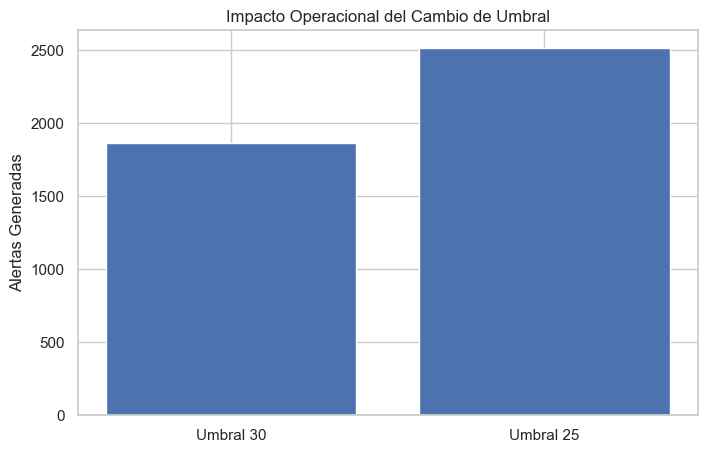

In [ ]:
cmp30 = threshold_report(y_test, pred_best, 30)
cmp25 = threshold_report(y_test, pred_best, best_threshold)
plt.figure(figsize=(8,5))
plt.bar(["Umbral 30", "Umbral 25"],
        [cmp30["Alertas_generadas"], cmp25["Alertas_generadas"]])
plt.title("Impacto Operacional del Cambio de Umbral")
plt.ylabel("Alertas Generadas")
plt.show()

In [ ]:
def minutes_to_hhmmss(m):
    m = int(round(m)) % 1440
    h = m // 60
    mm = m % 60
    return f"{h:02d}:{mm:02d}:00"

In [ ]:
ensure_dir("outputs/tables")

prior = X_test.copy()
prior["minutos_reales"] = y_test.values
prior["minutos_predichos"] = pred_best
prior["alerta_critica"] = prior["minutos_predichos"] > best_threshold

#HH:MM:SS
prior["hora_programada"] = prior["hora_programada_min"].apply(minutes_to_hhmmss)

# Orden: primero los más riesgosos
prior = prior.sort_values(["alerta_critica", "minutos_predichos"], ascending=[False, False])

cols_final = [
    "empresa","patente","tipo_operacion","tipo_carga","semana",
    "hora_programada","minutos_predichos","alerta_critica"
]

prior_final = prior[cols_final].head(20)
prior_final

,empresa,patente,tipo_operacion,tipo_carga,semana,hora_programada,minutos_predichos,alerta_critica
29898,CumbreKargo 24,TRK-032,Despacho,Carga Suelta,7,18:16:00,87.511086,True
15442,VentiscaLine Transport,TRK-004,Recepcion,Pallet,8,23:46:00,85.964676,True
1998,CumbreKargo 24,TRK-068,Despacho,Carga Suelta,49,22:07:00,85.760361,True
32650,SendaKrio Operaciones,TRK-021,Recepcion,Pallet,15,23:13:00,84.942818,True
3508,CumbreKargo 24,TRK-018,Recepcion,Pallet,43,21:48:00,83.896103,True
19582,VentiscaLine Transport,TRK-056,Recepcion,Carga Suelta,4,18:42:00,83.889069,True
34962,CumbreKargo 24,TRK-002,Recepcion,Carga Suelta,43,18:35:00,80.930153,True
14598,CumbreKargo 24,TRK-059,Recepcion,Pallet,16,19:35:00,80.148994,True
5101,VentiscaLine Transport,TRK-055,Recepcion,Carga Suelta,42,20:33:00,79.926872,True
33934,VentiscaLine Transport,TRK-068,Despacho,Carga Suelta,32,23:53:00,79.480377,True
